### PTE Prefetcher
* Translation-Only Tree-Aware Micro-Prefetcher
  - Goal: reduce PTW stall time, not maximize raw TXVC hit rate.(?)
  - Scope: only run when type == TRANSLATION.
  - Aggressiveness: start with degree 1, confidence-gated.
  - Safety: strict throttles and usefulness feedback.

* Core predictor components:

  * Translation stream table
    - Key: hashed requester IP plus translation level (if available).
    - State: last line, last delta, 2-bit confidence.
    - Trigger: issue one prefetch when the same delta repeats.

  * Page-table sibling predictor
    - Key: parent page-table page tag.
    - Idea: nearby virtual pages tend to touch nearby child PTEs; prefetch neighboring cache line within same page-table page, not blind global plus-one.
    - Constraint: never cross page-table-page boundary.
  
  * Usefulness controller
    - Track prefetched lines that become demand hits.
    - If rolling accuracy drops below threshold (for example 20%), auto-reduce degree to 0 until recovery.
    - Also gate on MSHR pressure like existing prefetchers do (same style as ip_stride.cc:67).

* Why it is better than naive plus-one:
  - It is still sequential-friendly when locality exists.
  - It avoids always assuming contiguous physical PTE layout.
  - long-tail regions? maybe this is why it doesn't work well for our case?

* Implementation notes:
  - using prefetcher metadata to add is_instr, translation_level 

* TXVC admission filter: (TODO)
  - Keep 2+ admission for demand fills.
  - For prefetch fills, apply stricter admission:
    - admit only if predictor confidence high, or
    - admit only for upper-level PTEs, or
    - admit into a tiny prefetch probation region (1 way per set).
    - Prevents low-value prefetched PTEs from displacing proven LFU residents.

* Evaluation:
  - Translation MPKI and average PTW latency.
  - IPC
  - Prefetch accuracy, coverage, and timeliness.
  - Pollution indicators: demand miss increase in L2/TXVC after enabling prefetch.
  - Breakdown by PTE level and by instruction/data streams.

  - Goal:
    - Keep prefetch accuracy above about 25% and MSHR pressure stable.
    - Accept lower TXVC hit-rate gains if PTW latency and IPC improve; this workload can benefit from latency hiding more than reuse capture.





### Prefetcher Implementation 

* Trigger on TXVC (demand) misses
* MSHR gating
  - do not issue prefetch if occupacy > N
* Optional: usefull_pf/useless_pf > M, else stop
  - Not sure when to resume

1. Stride Prefetcher:
  - Intuition:
    - If the PTW has been accessing PTE cache lines with a consistent stride, 
      predict the next one. (Global)

  - Prediction table:
    - cache line address
    - stride observed between the two last accesses
    - confidence, how many times this was observed
  
  - Limitatios:
    - Global context:
      - Can alias across different PTW levels
      - Can alias accross different code paths

    - Can prefetch across PT page boundaries (maybe fix?)


2. Siblings Prefetcher
  - Intuition:
    - PTEs for consecutive virtual pages share the same 4KB page-table page
    - If PTW accesses offset N within a PT page and then offset N+1, it will likely need N+2
    - The predictor tracks this intra-page stride
    - No cross-page prefetching

  - Predictor table:
    - Tag: id of the 4KB page
      - One entry per page
    - last offset observed
    - last stride observed (within page)
    - confindence: how many times this was observed
    - usefulness: was last time useful(?) (maybe start with 0 so it doesn't stop due to this metric)

  - Candidate is offset + k*delta (within page boundries)
    - k is how many candidates to look for, for now keep at 1, else multiple prefetches.


3. Child Prefetcher
  - Intuition:
    - A page walk is a chain of dependent loads: L5 -> L4 -> L3 -> L2 -> L1. 
    - If miss on first levels, we have to wait for it to be fetched to find the child (which will probably also result in a miss)
    - Try to learn IPs that walk the same virtual address range
    - Prefetch speculative child/children

  - Predictor table: (IP, parent_addr) -> child_addr
    - Index: IP hashd with PTE address
    - Child address: predicted child addr
    - confidence: how many times we observed this
  
  - Training table: last miss seen at each level
    - Index: IP % size
    - PTE address
    - PTE level

  - On miss:
    - Check training table[ip]
      - if it holds L+1 from the same ip, the current PTE is the child
    
    - Move (ip, L+1 addr) -> child addr to predictor table
      - Update confidence (+1 if match, reset otherwise)
    
    - Update training table:
      (ip, current pte addr, level) -> none/pending
    
    - If level > 1 (Leaf), emit prediction


  

### Analysis of the Stride Prefetcher

In [ ]:
./scripts/manage_experiment.py --config exp_conf/txvc_prefetch_eval.ini --build --run

In [13]:
%cd /home/bscuser/synched_mnt/VMem
!pwd
!./scripts/manage_experiment.py --config ./exp_conf/txvc_prefetch_eval.ini --parse

/home/bscuser/synched_mnt/VMem
/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/txvc_prefetch_eval/BASELINE', './data/txvc_prefetch_eval']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 4,223 bytes  2,849.33 bytes/sec
total size is 2,416,552  speedup is 565.41
Parsing results for BASELINE...
Merging results to ./stats/txvc_prefetch_eval/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/txvc_prefetch_eval/TXVC_64KB_pf-n

Preprocessing configuration file...
['BASELINE', 'TXVC_64KB_pf-none', 'TXVC_64KB_pf-stride', 'TXVC_64KB_pf-sibling', 'TXVC_128KB_pf-none', 'TXVC_128KB_pf-stride', 'TXVC_128KB_pf-sibling']
Plotting txvc_prefetch_eval for selected_qualcomm_srv_ap
['BASELINE', 'TXVC_64KB_pf-none', 'TXVC_64KB_pf-stride', 'TXVC_64KB_pf-sibling', 'TXVC_128KB_pf-none', 'TXVC_128KB_pf-stride', 'TXVC_128KB_pf-sibling']
                     tag  IPC_IMPROVEMENT
2   TXVC_128KB_pf-stride         5.437096
0     TXVC_128KB_pf-none         5.435732
1  TXVC_128KB_pf-sibling         5.435732
3      TXVC_64KB_pf-none         3.478636
5    TXVC_64KB_pf-stride         3.478636
4   TXVC_64KB_pf-sibling         3.477628
TXVC_64KB_pf-none:3.087772900069124
TXVC_64KB_pf-stride:3.089865945943952
TXVC_64KB_pf-sibling:3.0983165092870566
TXVC_128KB_pf-none:5.048761448801612
TXVC_128KB_pf-stride:5.046218194495493
TXVC_128KB_pf-sibling:5.047958411698207
  benchmarks                    tag      mean
0       mean      TXVC_64KB_pf-no

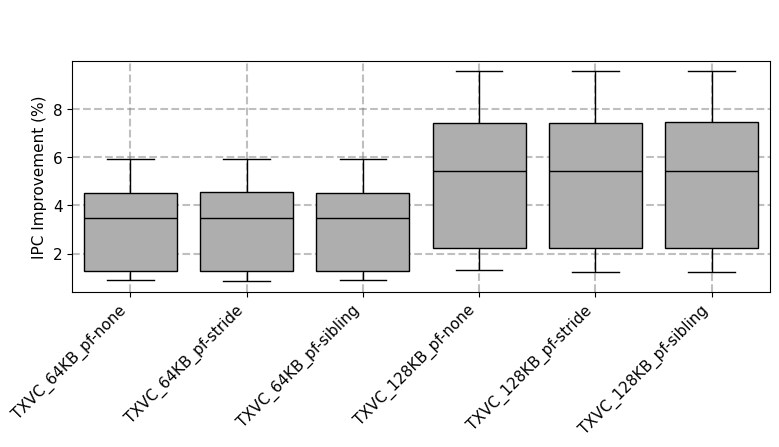

In [14]:
!./scripts/manage_experiment.py --config ./exp_conf/txvc_prefetch_eval.ini --plot

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_prefetch_eval_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))



### Parameter Sweep

* Sweep paramter space:
- txvc.pf_conf_threshold: 1,2,3
- txvc.pf_mshr_gate_pct: 25,40,50,60,75
- txvc.pf_table_size: 32,64,128,256 
  - We start with only 256, if things work, we will explore this dimension as well

* Good starting conservative conif:
  - txvc.pf_conf_threshold = 3
  - txvc.pf_mshr_gate_pct = 40
  - txvc.pf_table_size = 128

In [ ]:
./scripts/manage_experiment.py --config exp_conf/txvc_prefetch_param_sweep.ini --build --run

In [31]:
!cd ..
!./scripts/manage_experiment.py --config ./exp_conf/txvc_prefetch_param_sweep.ini --parse

Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/txvc_prefetch_eval/BASELINE', './data/txvc_prefetch_eval']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 4,223 bytes  2,849.33 bytes/sec
total size is 2,416,552  speedup is 565.41
Parsing results for BASELINE...
Merging results to ./stats/txvc_prefetch_eval/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/txvc_prefetch_eval/TXVC_64KB_pf-none', './data/txvc_prefetch_eval']
/home/bsc/bsc018186/.bashrc

Preprocessing configuration file...
['BASELINE', 'TXVC_64KB_pf-none', 'TXVC_64KB_pf-stride_thld-1_gate-25_tblsize-256', 'TXVC_64KB_pf-stride_thld-2_gate-25_tblsize-256', 'TXVC_64KB_pf-stride_thld-3_gate-25_tblsize-256', 'TXVC_64KB_pf-stride_thld-1_gate-40_tblsize-256', 'TXVC_64KB_pf-stride_thld-2_gate-40_tblsize-256', 'TXVC_64KB_pf-stride_thld-3_gate-40_tblsize-256', 'TXVC_64KB_pf-stride_thld-1_gate-50_tblsize-256', 'TXVC_64KB_pf-stride_thld-2_gate-50_tblsize-256', 'TXVC_64KB_pf-stride_thld-3_gate-50_tblsize-256', 'TXVC_64KB_pf-stride_thld-1_gate-60_tblsize-256', 'TXVC_64KB_pf-stride_thld-2_gate-60_tblsize-256', 'TXVC_64KB_pf-stride_thld-3_gate-60_tblsize-256', 'TXVC_64KB_pf-stride_thld-1_gate-75_tblsize-256', 'TXVC_64KB_pf-stride_thld-2_gate-75_tblsize-256', 'TXVC_64KB_pf-stride_thld-3_gate-75_tblsize-256']
Plotting txvc_prefetch_param_sweep for selected_qualcomm_srv_ap
['BASELINE', 'TXVC_64KB_pf-none', 'TXVC_64KB_pf-stride_thld-1_gate-25_tblsize-256', 'TXVC_64KB_pf-stride_thld-2_gate

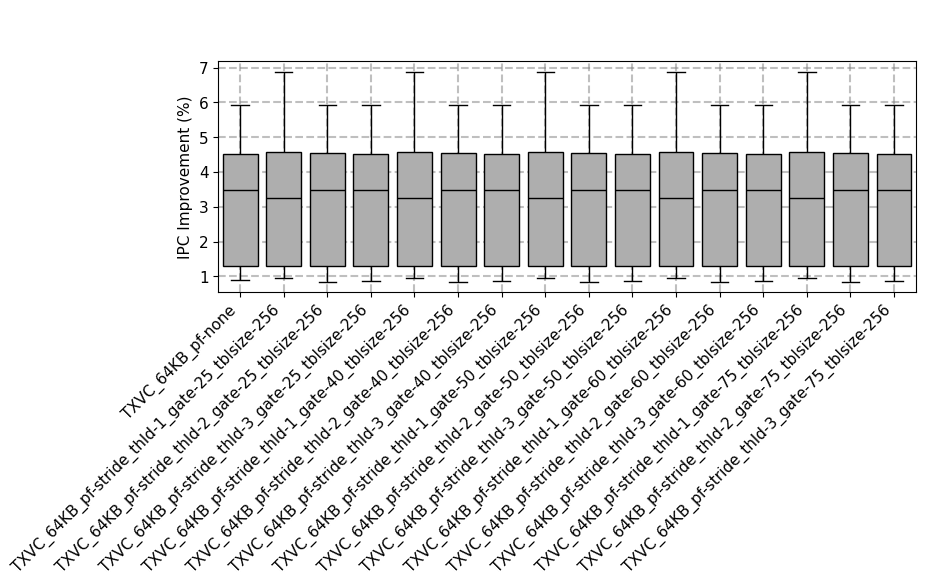

In [32]:
!cd ..
!./scripts/manage_experiment.py --config ./exp_conf/txvc_prefetch_param_sweep.ini --plot

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_prefetch_param_sweep_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

### Analysis of the Sibling Prefetcher


### Improvements

* Dynamic admission threshold
  - Switch between access threshold 2 and 3 based on recent miss burstiness or queue pressure.

### Morrigan-like
Short answer: partially relevant, but probably too heavy as-is for your use case.

* Learn richer access correlations than simple stride.
  - PTE streams are often non-linear, so richer correlation than plus-one/stride can find extra hits.
  - That can help with long-tail reuse.
  - Use context like walker IP, translation level, and recent deltas to predict next PTE lines.

* Use a tiny correlation table keyed by (IP hash, translation level, page-table-page tag).
  - Degree 1 by default, degree 2 only at high confidence.
  - Add strict usefulness feedback (auto-throttle when accuracy drops).

### Synergy with replacement:
* Separate LFU counters for demand and prefetched lines
* Prefetch hits should need to prove usefulness before getting full LFU weight.